<a href="https://colab.research.google.com/github/Naman1232/ML-PROJECTS/blob/main/Time_Series_Forecasting_with_SARIMA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
plt.style.use('dark_background')

In [2]:
from google.colab import files
uploaded = files.upload()

Saving AirPassengers.csv to AirPassengers.csv


In [3]:
df = pd.read_csv('AirPassengers.csv')
print(df.head)

<bound method NDFrame.head of        Month  #Passengers
0    1949-01          112
1    1949-02          118
2    1949-03          132
3    1949-04          129
4    1949-05          121
..       ...          ...
139  1960-08          606
140  1960-09          508
141  1960-10          461
142  1960-11          390
143  1960-12          432

[144 rows x 2 columns]>


In [4]:
df['Month'] = pd.to_datetime(df['Month'])
print(df.head)

<bound method NDFrame.head of          Month  #Passengers
0   1949-01-01          112
1   1949-02-01          118
2   1949-03-01          132
3   1949-04-01          129
4   1949-05-01          121
..         ...          ...
139 1960-08-01          606
140 1960-09-01          508
141 1960-10-01          461
142 1960-11-01          390
143 1960-12-01          432

[144 rows x 2 columns]>


In [5]:
df.set_index('Month', inplace=True)
print(df.head())

            #Passengers
Month                  
1949-01-01          112
1949-02-01          118
1949-03-01          132
1949-04-01          129
1949-05-01          121


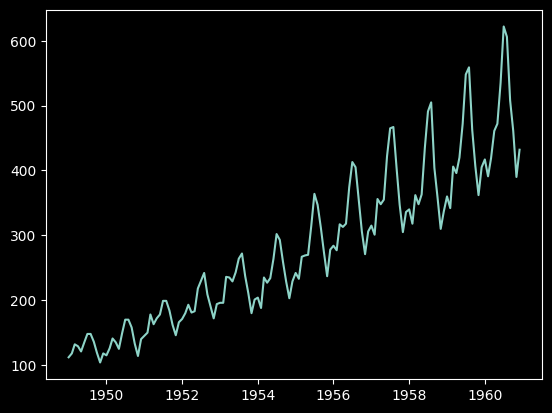

In [6]:
plt.plot(df['#Passengers'])

In [7]:
from statsmodels.tsa.stattools import adfuller
adf, pvalue, usedlag_, nobs_, critical_values_, icbest_ = adfuller(df)
print("pvalue = ", pvalue, " if above 0.05, data is not stationary")

pvalue =  0.991880243437641  if above 0.05, data is not stationary


In [8]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposed = seasonal_decompose(df['#Passengers'],
                            model ='additive')
trend = decomposed.trend
seasonal = decomposed.seasonal
residual = decomposed.resid

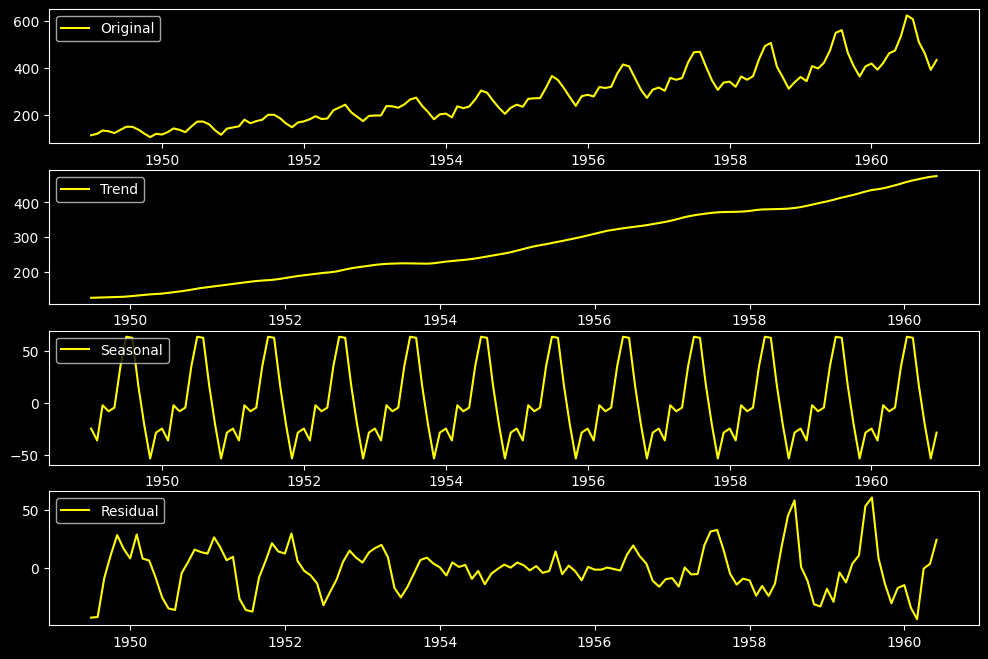

In [9]:
plt.figure(figsize=(12,8))
plt.subplot(411)
plt.plot(df['#Passengers'], label='Original', color='yellow')
plt.legend(loc='upper left')
plt.subplot(412)
plt.plot(trend, label='Trend', color='yellow')
plt.legend(loc='upper left')
plt.subplot(413)
plt.plot(seasonal, label='Seasonal', color='yellow')
plt.legend(loc='upper left')
plt.subplot(414)
plt.plot(residual, label='Residual', color='yellow')
plt.legend(loc='upper left')
plt.show()

In [15]:
size = int(len(df) * 0.66)
X_train, X_test = df.iloc[:size], df.iloc[size:]

In [18]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
model = SARIMAX(X_train['#Passengers'],
                order=(0, 1, 1),
                seasonal_order=(2, 1, 1, 12),
                enforce_stationarity=False,
                enforce_invertibility=False)

result = model.fit()
print(result.summary())

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                        #Passengers   No. Observations:                   95
Model:             SARIMAX(0, 1, 1)x(2, 1, 1, 12)   Log Likelihood                -217.057
Date:                            Wed, 28 May 2025   AIC                            444.114
Time:                                    11:39:52   BIC                            454.416
Sample:                                01-01-1949   HQIC                           448.127
                                     - 11-01-1956                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.2697      0.126     -2.148      0.032      -0.516      -0.024
ar.S.L12      -0.5560      0.448   

* Imports the SARIMAX model for time series forecasting.
* Uses `#Passengers` column from training data.
* `order=(0,1,1)`: 1st order differencing, 1 MA term.
* `seasonal_order=(2,1,1,12)`: Captures yearly seasonality (monthly data).
* Disables stationarity and invertibility checks.
* Fits the model on training data.
* Prints a summary of the model's fit and parameters.


In [20]:
test_pred = result.predict(start=len(X_train), end=len(df)-1)
test_pred = test_pred.rename('Predicted Passengers')

* We **use the trained model to make predictions** on the test data period.
* Then, we **compare those predicted values with the actual test data** to see how well the model performs.


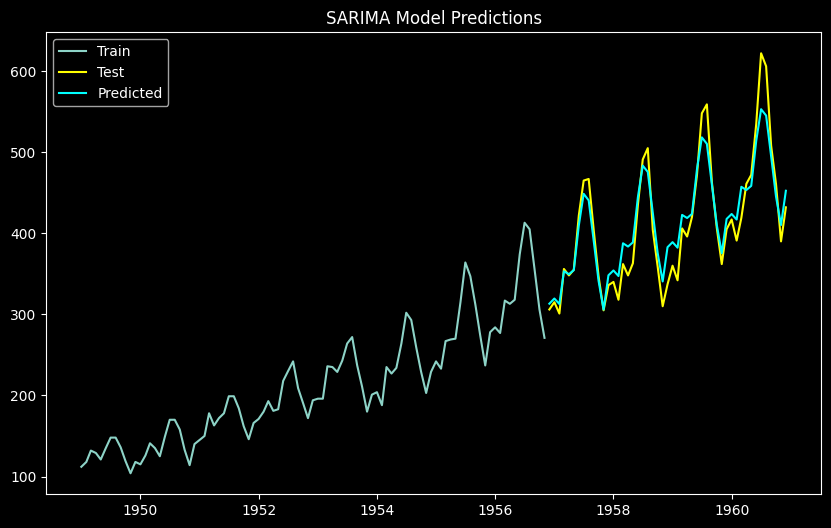

In [22]:
plt.figure(figsize=(10,6))
plt.plot(X_train.index, X_train['#Passengers'], label='Train')
plt.plot(X_test.index, X_test['#Passengers'], label='Test', color='yellow')
plt.plot(X_test.index, test_pred, label='Predicted', color='cyan')
plt.legend()
plt.title("SARIMA Model Predictions")
plt.show()

In [25]:
import math
from sklearn.metrics import mean_squared_error
train_rmse = math.sqrt(mean_squared_error(X_train['#Passengers'], train_pred))
test_rmse = math.sqrt(mean_squared_error(X_test['#Passengers'], test_pred))
print(f"Train RMSE: {train_rmse:.2f}")
print(f"Test RMSE: {test_rmse:.2f}")

Train RMSE: 16.44
Test RMSE: 24.59


In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
y_true = X_test['#Passengers']
y_pred = test_pred

# 1. Mean Absolute Error (MAE)
mae = mean_absolute_error(y_true, y_pred)

# 2. Mean Squared Error (MSE)
mse = mean_squared_error(y_true, y_pred)

# 3. Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

# 4. R-squared (Coefficient of Determination)
r2 = r2_score(y_true, y_pred)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R-squared: {r2:.2f}")

mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100


accuracy = 100 - mape

print(f"MAPE: {mape:.2f}%")
print(f"Accuracy: {accuracy:.2f}%")


MAE: 19.39
MSE: 604.75
RMSE: 24.59
R-squared: 0.90
MAPE: 4.66%
Accuracy: 95.34%


 MAPE basically tells you **how much your predictions are wrong on average, expressed as a percentage**. The lower the MAPE, the smaller the error and the better your predictions.


In [26]:
forecast = result.predict(start=len(df),
                          end=len(df) + 36 - 1,
                          typ='levels').rename('Forecast')


forecast_df = forecast.to_frame()
forecast_df.index = pd.date_range(start=df.index[-1] + pd.offsets.MonthBegin(),
                                 periods=36, freq='MS')
print(forecast_df)


              Forecast
1961-01-01  458.604967
1961-02-01  451.782540
1961-03-01  492.175303
1961-04-01  488.321055
1961-05-01  493.373335
1961-06-01  548.896760
1961-07-01  587.839256
1961-08-01  579.928899
1961-09-01  529.694460
1961-10-01  480.282716
1961-11-01  444.989164
1961-12-01  487.266881
1962-01-01  493.363357
1962-02-01  486.533469
1962-03-01  526.919034
1962-04-01  523.013545
1962-05-01  528.083768
1962-06-01  583.723858
1962-07-01  622.613551
1962-08-01  614.746604
1962-09-01  564.449043
1962-10-01  515.017034
1962-11-01  479.767146
1962-12-01  522.037537
1963-01-01  528.169316
1963-02-01  521.343962
1963-03-01  561.733901
1963-04-01  557.859546
1963-05-01  562.918866
1963-06-01  618.488071
1963-07-01  657.409847
1963-08-01  649.516524
1963-09-01  599.257316
1963-10-01  549.837620
1963-11-01  514.561202
1963-12-01  556.836044


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['typ']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


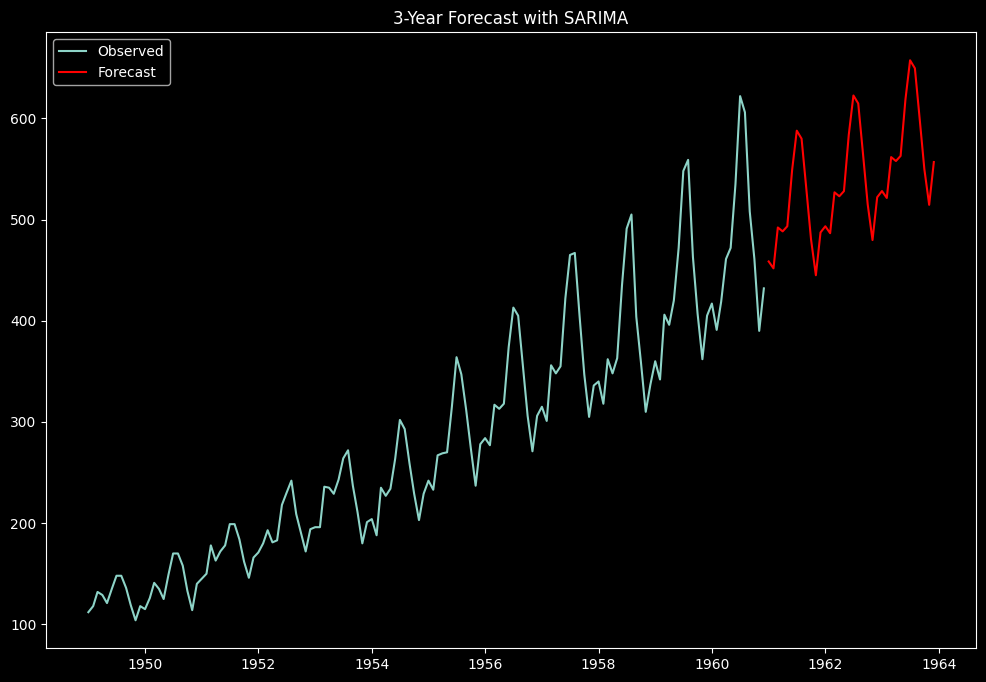

In [30]:
plt.figure(figsize=(12,8))
plt.plot(df.index, df['#Passengers'], label='Observed')
plt.plot(forecast.index, forecast, label='Forecast', color='red')
plt.legend()
plt.title("3-Year Forecast with SARIMA")
plt.show()